# Data exploration
Data exploratin of the final dataset: 
- day, pos, number of vessel, bgc variables 

# Set

In [1]:
import numpy as np
import pandas as pd
import sklearn

print("Notebook AIPS check")
print(np.__version__)
print(pd.__version__)
print(sklearn.__version__)

import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Notebook AIPS check
2.2.6
2.3.3
1.7.2


In [17]:
YEAR = 2025

# Data folders
raw_folder = "data/raw/"
interim_folder = "data/interim/"
processed_folder = "data/processed/"

# Dataset names 
cpr_gfw_dp_name = f"cpr_gfw_{YEAR}.parquet"
ais_dp_name = f"gfw_ais/cleaned_ais_high_daily_ts_{YEAR}.parquet"
s2_dp_name = f"gfw_sar/cleaned_s2_vessel_detections_{YEAR}.parquet"
gulf_coords_dp_name = "ts_gulf_coords.csv"

# Import 

In [18]:
cpr_gfw = pd.read_parquet(f"{processed_folder}{cpr_gfw_dp_name}")

ais = pd.read_parquet(f"{interim_folder}{ais_dp_name}")
sar = pd.read_parquet(f"{interim_folder}{s2_dp_name}")

gulf_coords = pd.read_csv(f"{raw_folder}{gulf_coords_dp_name}")

# Trawlers vs other - spatial analysis 

In [19]:
sar_unq_coords = sar[['latitude', 'longitude']].drop_duplicates()
ais_unq_coords = ais[['latitude', 'longitude']].drop_duplicates()

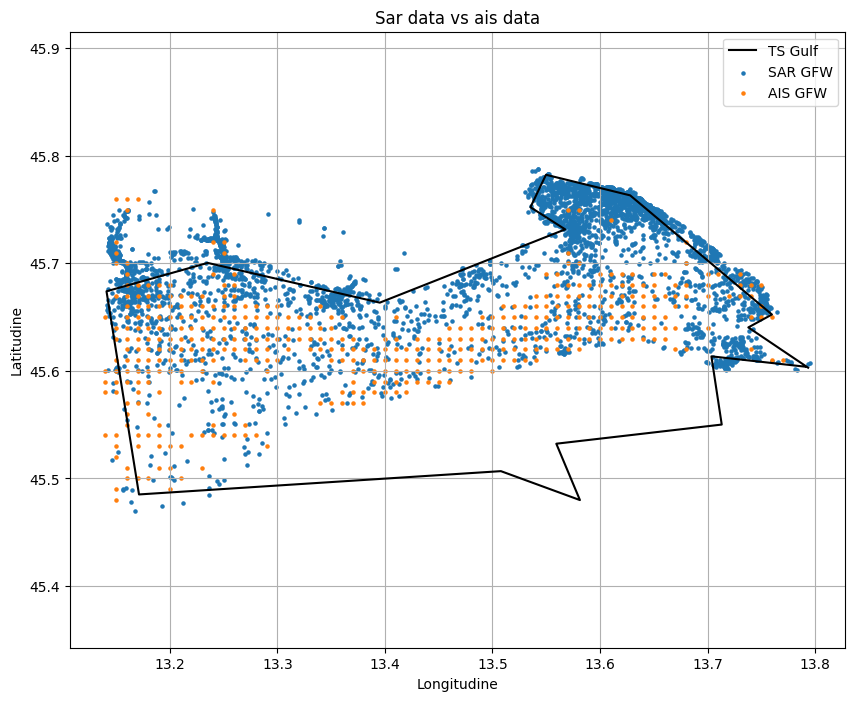

In [20]:
plt.figure(figsize=(10,8))

plt.plot(gulf_coords['longitude'], gulf_coords['latitude'], label = 'TS Gulf', color = 'black')
plt.scatter(sar_unq_coords['longitude'], sar_unq_coords['latitude'], label = 'SAR GFW', s = 5)
plt.scatter(ais_unq_coords['longitude'], ais_unq_coords['latitude'], label = 'AIS GFW', s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.title("Sar data vs ais data")
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()

In [21]:
trawlers_condition = ais['gear_type'] == 'TRAWLERS'
pots_and_traps_condition = ais['gear_type'] == 'POTS_AND_TRAPS'
dredge_fishing_condition = ais['gear_type'] == 'DREDGE_FISHING'
other_purse_seines_condition = ais['gear_type'] == 'OTHER_PURSE_SEINES'
fishing_condition = ais['gear_type'] == 'FISHING'   

ais_trawlers = ais[trawlers_condition].copy()
ais_n_trawlers = ais[~trawlers_condition].copy()
ais_pots_and_traps = ais[pots_and_traps_condition].copy()
ais_dredge_fishing = ais[dredge_fishing_condition].copy()
ais_other_purse_seines = ais[other_purse_seines_condition].copy()
ais_fishing = ais[fishing_condition].copy()


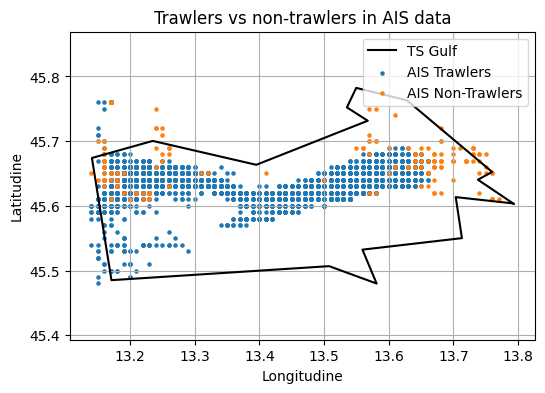

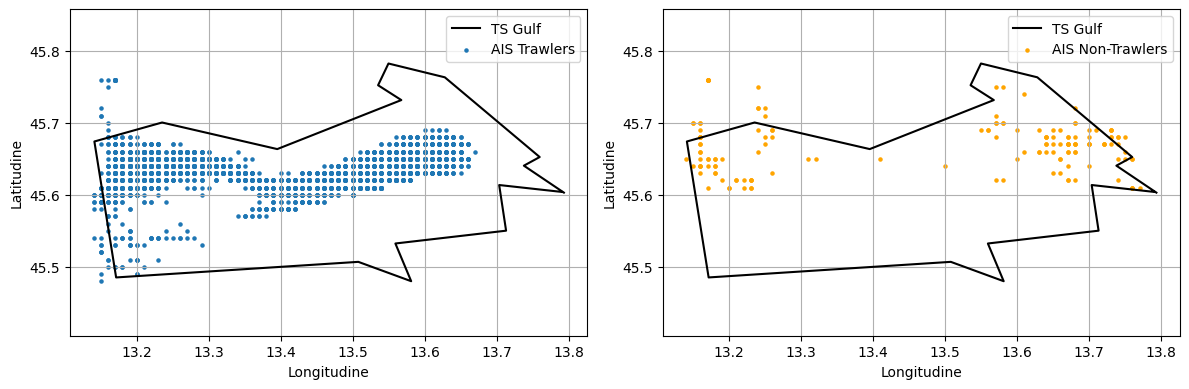

In [22]:
plt.figure(figsize=(6,4))

plt.plot(gulf_coords['longitude'], gulf_coords['latitude'], label = 'TS Gulf', color = 'black')
plt.scatter(ais_trawlers['longitude'], ais_trawlers['latitude'], label = 'AIS Trawlers', s = 5)
plt.scatter(ais_n_trawlers['longitude'], ais_n_trawlers['latitude'], label = 'AIS Non-Trawlers', s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.title("Trawlers vs non-trawlers in AIS data")
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Primo subplot: Trawlers ---
axes[0].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[0].scatter(ais_trawlers['longitude'], ais_trawlers['latitude'], s=5, label='AIS Trawlers')
axes[0].set_xlim(13, 14)
axes[0].set_ylim(45.3, 45.9)
axes[0].set_xlabel("Longitudine")
axes[0].set_ylabel("Latitudine")
axes[0].grid(True)
axes[0].axis("equal")
axes[0].legend()

# --- Secondo subplot: Non-Trawlers ---
axes[1].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[1].scatter(ais_n_trawlers['longitude'], ais_n_trawlers['latitude'], s=5, color='orange', label='AIS Non-Trawlers')
axes[1].set_xlim(13, 14)
axes[1].set_ylim(45.3, 45.9)
axes[1].set_xlabel("Longitudine")
axes[1].set_ylabel("Latitudine")
axes[1].grid(True)
axes[1].axis("equal")
axes[1].legend()

plt.tight_layout()
plt.show()


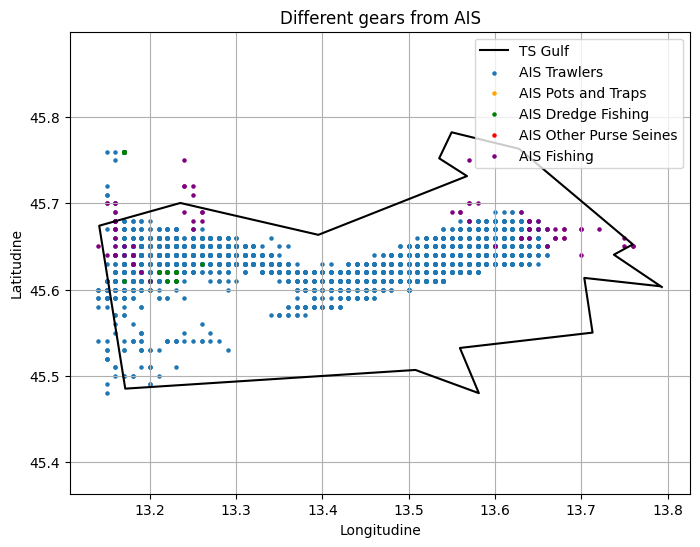

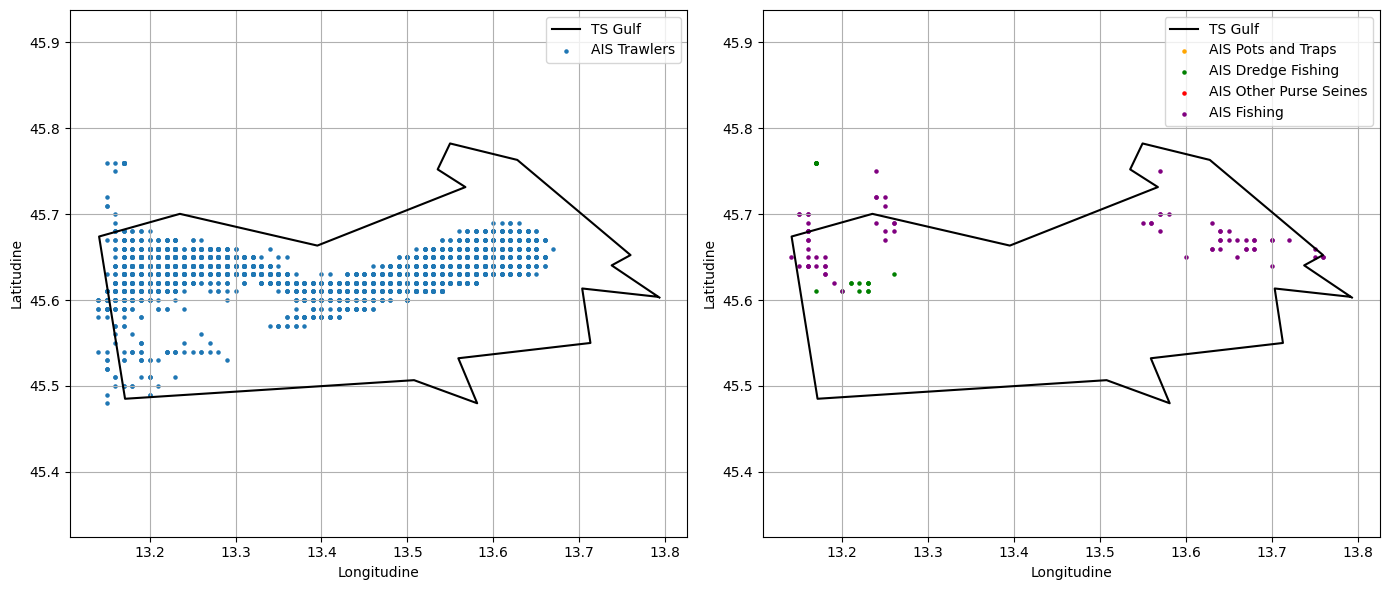

In [23]:
plt.figure(figsize=(8,6))

plt.plot(gulf_coords['longitude'], gulf_coords['latitude'], label = 'TS Gulf', color = 'black')
plt.scatter(ais_trawlers['longitude'], ais_trawlers['latitude'], label = 'AIS Trawlers', s = 5)
plt.scatter(ais_pots_and_traps['longitude'], ais_pots_and_traps['latitude'], label = 'AIS Pots and Traps', s = 5, color = 'orange')
plt.scatter(ais_dredge_fishing['longitude'], ais_dredge_fishing['latitude'], label = 'AIS Dredge Fishing', s = 5, color = 'green')
plt.scatter(ais_other_purse_seines['longitude'], ais_other_purse_seines['latitude'], label = 'AIS Other Purse Seines', s = 5, color = 'red')
plt.scatter(ais_fishing['longitude'], ais_fishing['latitude'], label = 'AIS Fishing', s = 5, color = 'purple')
plt.title("Different gears from AIS")
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -------------------------------
# SUBPLOT 1 — AIS Trawlers
# -------------------------------
axes[0].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[0].scatter(ais_trawlers['longitude'], ais_trawlers['latitude'], s=5, label='AIS Trawlers')

axes[0].set_xlim(13, 14)
axes[0].set_ylim(45.3, 45.9)
axes[0].set_xlabel("Longitudine")
axes[0].set_ylabel("Latitudine")
axes[0].grid(True)
axes[0].axis("equal")
axes[0].legend()


# -------------------------------
# SUBPLOT 2 — Altri attrezzi (Pots, Dredge, Purse Seines, Fishing)
# -------------------------------
axes[1].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[1].scatter(ais_pots_and_traps['longitude'], ais_pots_and_traps['latitude'], s=5, label='AIS Pots and Traps', color='orange')
axes[1].scatter(ais_dredge_fishing['longitude'], ais_dredge_fishing['latitude'], s=5, label='AIS Dredge Fishing', color='green')
axes[1].scatter(ais_other_purse_seines['longitude'], ais_other_purse_seines['latitude'], s=5, label='AIS Other Purse Seines', color='red')
axes[1].scatter(ais_fishing['longitude'], ais_fishing['latitude'], s=5, label='AIS Fishing', color='purple')

axes[1].set_xlim(13, 14)
axes[1].set_ylim(45.3, 45.9)
axes[1].set_xlabel("Longitudine")
axes[1].set_ylabel("Latitudine")
axes[1].grid(True)
axes[1].axis("equal")
axes[1].legend()


plt.tight_layout()
plt.show()


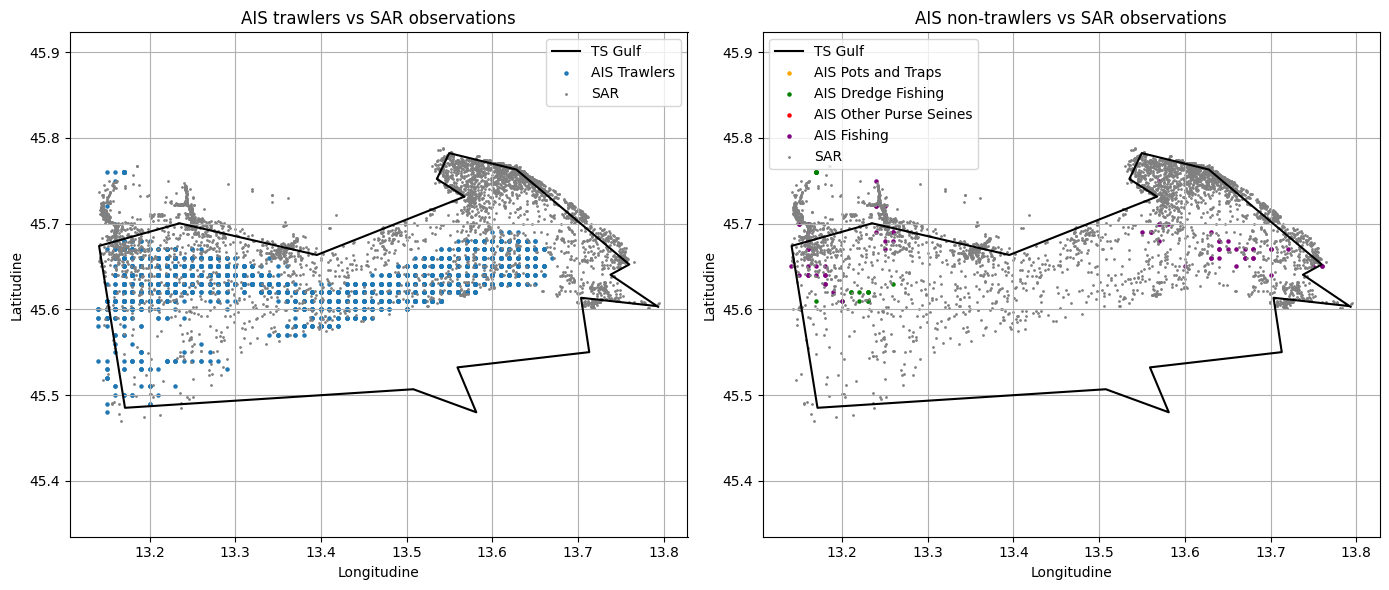

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -------------------------------
# SUBPLOT 1 — AIS Trawlers
# -------------------------------
axes[0].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[0].scatter(ais_trawlers['longitude'], ais_trawlers['latitude'], s=5, label='AIS Trawlers')
axes[0].scatter(sar['longitude'], sar['latitude'], s=1, label='SAR', color = 'grey')

axes[0].set_title("AIS trawlers vs SAR observations")
axes[0].set_xlim(13, 14)
axes[0].set_ylim(45.3, 45.9)
axes[0].set_xlabel("Longitudine")
axes[0].set_ylabel("Latitudine")
axes[0].grid(True)
axes[0].axis("equal")
axes[0].legend()


# -------------------------------
# SUBPLOT 2 — Altri attrezzi (Pots, Dredge, Purse Seines, Fishing)
# -------------------------------
axes[1].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[1].scatter(ais_pots_and_traps['longitude'], ais_pots_and_traps['latitude'], s=5, label='AIS Pots and Traps', color='orange')
axes[1].scatter(ais_dredge_fishing['longitude'], ais_dredge_fishing['latitude'], s=5, label='AIS Dredge Fishing', color='green')
axes[1].scatter(ais_other_purse_seines['longitude'], ais_other_purse_seines['latitude'], s=5, label='AIS Other Purse Seines', color='red')
axes[1].scatter(ais_fishing['longitude'], ais_fishing['latitude'], s=5, label='AIS Fishing', color='purple')
axes[1].scatter(sar['longitude'], sar['latitude'], s=1, label='SAR', color = 'grey')

axes[1].set_title("AIS non-trawlers vs SAR observations")
axes[1].set_xlim(13, 14)
axes[1].set_ylim(45.3, 45.9)
axes[1].set_xlabel("Longitudine")
axes[1].set_ylabel("Latitudine")
axes[1].grid(True)
axes[1].axis("equal")
axes[1].legend()


plt.tight_layout()
plt.show()

# Day by day - spatial analysis 

In [25]:
import math
import pandas as pd
import matplotlib.pyplot as plt


def plot_daily_detection_maps(
    ais=None,
    sar=None,
    gulf_coords=None,
    start_date="2024-12-01",
    end_date="2024-12-10",
    source="ais",  # "ais", "sar", or "both"
    ais_date_col="date",
    sar_date_col="date",
    lon_col="longitude",
    lat_col="latitude",
    xlim=(13, 14),
    ylim=(45.3, 45.9),
    ncols=5,
    point_size=8,
):
    """
    Plot daily AIS/SAR detections on the Gulf of Trieste map.

    Parameters
    ----------
    ais:
        AIS dataframe.
    sar:
        SAR/Sentinel dataframe.
    gulf_coords:
        DataFrame with Gulf boundary coordinates.
    start_date, end_date:
        Date range to plot.
    source:
        "ais", "sar", or "both".
    ais_date_col, sar_date_col:
        Date column names for AIS and SAR datasets.
    """

    if source not in ["ais", "sar", "both"]:
        raise ValueError("source must be one of: 'ais', 'sar', 'both'")

    if source in ["ais", "both"] and ais is None:
        raise ValueError("AIS dataframe must be provided when source is 'ais' or 'both'.")

    if source in ["sar", "both"] and sar is None:
        raise ValueError("SAR dataframe must be provided when source is 'sar' or 'both'.")

    if gulf_coords is None:
        raise ValueError("gulf_coords must be provided.")

    start_date = pd.to_datetime(start_date).normalize()
    end_date = pd.to_datetime(end_date).normalize()
    dates = pd.date_range(start_date, end_date, freq="D")

    ais_plot = None
    sar_plot = None

    if ais is not None:
        ais_plot = ais.copy()
        ais_plot[ais_date_col] = pd.to_datetime(ais_plot[ais_date_col]).dt.normalize()

    if sar is not None:
        sar_plot = sar.copy()
        sar_plot[sar_date_col] = pd.to_datetime(sar_plot[sar_date_col]).dt.normalize()

    n_days = len(dates)
    nrows = math.ceil(n_days / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4 * ncols, 4 * nrows),
        squeeze=False,
    )

    axes_flat = axes.ravel()

    for ax, current_date in zip(axes_flat, dates):

        ax.plot(
            gulf_coords[lon_col],
            gulf_coords[lat_col],
            color="black",
            linewidth=1,
            label="TS Gulf",
        )

        if source in ["ais", "both"]:
            ais_day = ais_plot[ais_plot[ais_date_col] == current_date]

            ax.scatter(
                ais_day[lon_col],
                ais_day[lat_col],
                s=point_size,
                alpha=0.8,
                label=f"AIS ({len(ais_day)})",
            )

        if source in ["sar", "both"]:
            sar_day = sar_plot[sar_plot[sar_date_col] == current_date]

            ax.scatter(
                sar_day[lon_col],
                sar_day[lat_col],
                s=point_size,
                alpha=0.8,
                marker="x",
                label=f"SAR ({len(sar_day)})",
            )

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_title(current_date.strftime("%Y-%m-%d"))
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.grid(True, alpha=0.3)
        ax.axis("equal")
        ax.legend(fontsize=8)

    for ax in axes_flat[n_days:]:
        ax.axis("off")

    fig.suptitle(
        f"{source.upper()} detections from {start_date.date()} to {end_date.date()}",
        fontsize=16,
    )

    fig.tight_layout()
    plt.show()

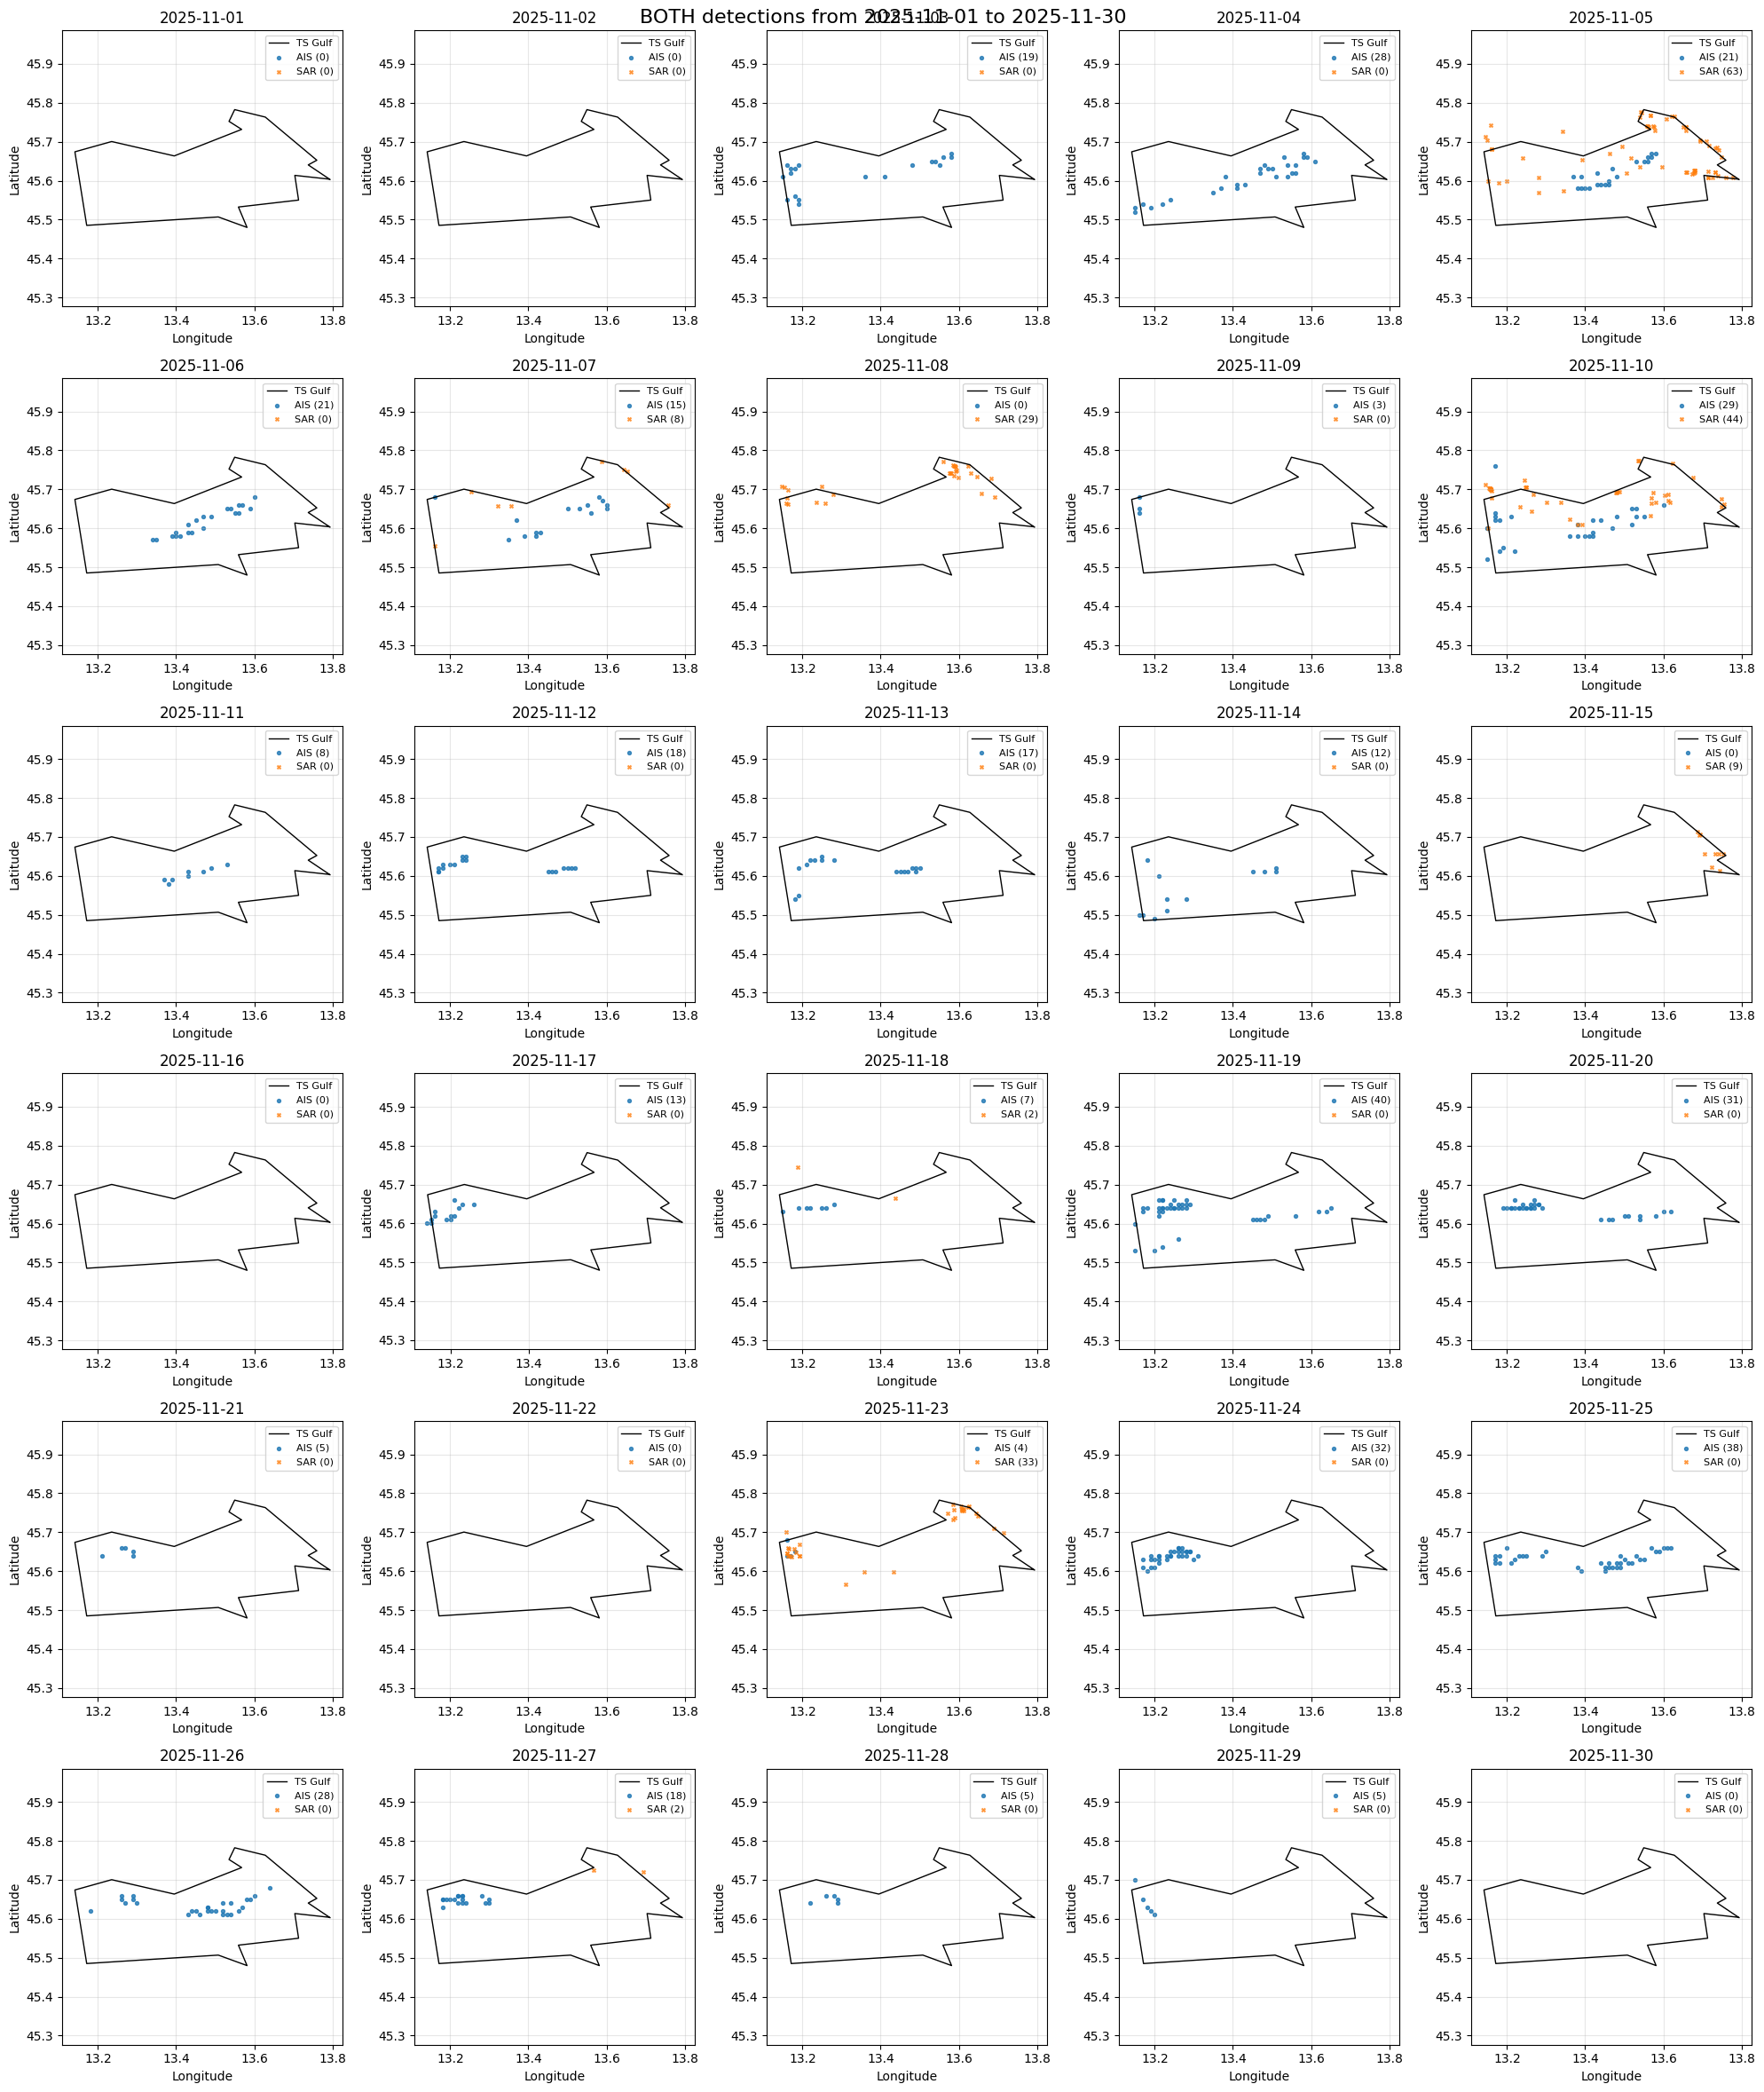

In [78]:
plot_daily_detection_maps(
    ais=ais,
    sar=sar,
    gulf_coords=gulf_coords,
    start_date="2025-11-01",
    end_date="2025-11-30",
    source="both", # ais OR sar OR both
)

## AIS points versus LGCP-style observed maps

Each group shows the same days in three rows: AIS locations, unsmoothed grid counts, and the Gaussian RBF surface from `viz_lgcp.py`. The interpolation can overshoot actual counts. Coordinates, grid resolution, clipping and Gulf masking follow the experiment. No model training is required. The shared count scale defaults to observed counts; set `vmax` to match an experiment figure.


In [79]:
from pathlib import Path as FilePath
import sys
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path as PolygonPath
from scipy.interpolate import Rbf
from scipy import ndimage
import yaml

# Work from either the repository root or notebooks/.
PROJECT_ROOT = next(p for p in [FilePath.cwd(), *FilePath.cwd().parents]
                    if (p / 'src/visualization/viz_lgcp.py').exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.models.data_pp_lgcp import prepare_data, compute_meta, make_day_split_masks


def plot_daily_lgcp_observation_comparison(
    ais, config_path='config/exp4.yaml', start_date=None, end_date=None,
    ncols=3, point_size=12, nx=150, ny=100, vmax=None,
):
    """Compare AIS locations, grid counts, and the viz_lgcp Gaussian RBF surface.

    Uses the experiment's data split/scalers without training a model.
    Dates default to its test window; set vmax to the experiment colorbar
    maximum to match its saturation (which also depends on predictions).
    """
    if ncols < 1:
        raise ValueError('ncols must be positive')
    with open(PROJECT_ROOT / config_path) as f:
        cfg = yaml.safe_load(f)
    prepared = prepare_data(
        str(PROJECT_ROOT / cfg['parquet_path']),
        train_fraction=cfg['train_fraction'], random_seed=cfg['data_seed'],
        split_strategy=cfg.get('split_strategy', 'random_day'),
        covariate_cols=cfg.get('covariate_cols'),
        test_start_date=cfg.get('test_start_date'), test_end_date=cfg.get('test_end_date'),
        lag_features=cfg.get('lag_features'), years=cfg.get('years'),
    )
    _, _, _, coords, _, counts, _, frame = prepared
    meta = compute_meta(frame)
    _, test_mask = make_day_split_masks(
        frame, train_fraction=cfg['train_fraction'], random_seed=cfg['data_seed'],
        split_strategy=cfg.get('split_strategy', 'random_day'),
        test_start_date=cfg.get('test_start_date'), test_end_date=cfg.get('test_end_date'),
    )
    dates = pd.DatetimeIndex(frame.loc[test_mask, 'date']).normalize()
    start = pd.Timestamp(start_date or dates.min()).normalize()
    end = pd.Timestamp(end_date or dates.max()).normalize()
    days = sorted(dates[(dates >= start) & (dates <= end)].unique())
    if not days:
        raise ValueError('No test days in requested range; choose dates within the config test window.')
    gulf = pd.read_csv(PROJECT_ROOT / cfg['gulf_csv_path'])
    mean = np.array([meta['lon_mean'], meta['lat_mean']])
    std = np.array([meta['lon_std'], meta['lat_std']])
    boundary = (gulf[['longitude', 'latitude']].to_numpy() - mean) / std
    xi = np.linspace(boundary[:, 0].min(), boundary[:, 0].max(), nx)
    yi = np.linspace(boundary[:, 1].min(), boundary[:, 1].max(), ny)
    Xi, Yi = np.meshgrid(xi, yi)
    inside = PolygonPath(boundary).contains_points(np.c_[Xi.ravel(), Yi.ravel()]).reshape(Xi.shape)
    ais_dates = pd.to_datetime(ais['date']).dt.normalize()
    vmax = max(float(np.max(counts)), 1e-8) if vmax is None else vmax
    fig, axes = plt.subplots(3 * math.ceil(len(days) / ncols), ncols,
                             figsize=(4.5 * ncols, 11 * math.ceil(len(days) / ncols)),
                             squeeze=False)
    for ax in axes.flat:
        ax.set_visible(False)
    summary = []
    for i, day in enumerate(days):
        group, col = divmod(i, ncols)
        axs = [axes[group * 3 + row, col] for row in range(3)]
        mask = dates == day
        x, y = coords[mask, 0], coords[mask, 1]
        values = np.asarray(counts[mask], dtype=float)
        # Same interpolation, clipping, NaN handling and polygon mask as viz_lgcp.
        interpolated = np.clip(Rbf(x, y, values, function='gaussian')(Xi, Yi), 0, None)
        nan_mask = np.isnan(interpolated)
        if nan_mask.any():
            interpolated[nan_mask] = ndimage.generic_filter(interpolated, np.nanmean, size=3)[nan_mask]
        surface = np.where(inside, interpolated, np.nan)
        points = ais.loc[ais_dates == day, ['longitude', 'latitude']].to_numpy()
        points = (points - mean) / std
        axs[0].scatter(points[:, 0], points[:, 1], s=point_size, color='tab:blue')
        cell_plot = axs[1].scatter(x, y, c=values, marker='s', s=55,
                                   cmap='viridis', vmin=0, vmax=vmax)
        smooth_plot = axs[2].imshow(surface, origin='lower',
                                    extent=[xi.min(), xi.max(), yi.min(), yi.max()],
                                    cmap='viridis', aspect='auto', vmin=0, vmax=vmax)
        for ax, label in zip(axs, [f'AIS points ({len(points)})',
                                  f'Grid counts (total {values.sum():g})',
                                  'Observed counts — Gaussian RBF']):
            ax.set_visible(True)
            ax.plot(boundary[:, 0], boundary[:, 1], color='red', lw=1.2)
            ax.set(xlim=(xi.min(), xi.max()), ylim=(yi.min(), yi.max()),
                   title=f'{day:%Y-%m-%d}\n{label}',
                   xlabel='Longitude (standardized)', ylabel='Latitude (standardized)')
        for ax, artist in [(axs[1], cell_plot), (axs[2], smooth_plot)]:
            fig.colorbar(artist, ax=ax, fraction=.046, pad=.04)
        summary.append({'date': day, 'AIS records': len(points),
                        'grid total': values.sum(), 'max cell count': values.max(),
                        'max interpolated value': np.nanmax(surface)})
    fig.tight_layout()
    plt.show()
    return pd.DataFrame(summary)


Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']


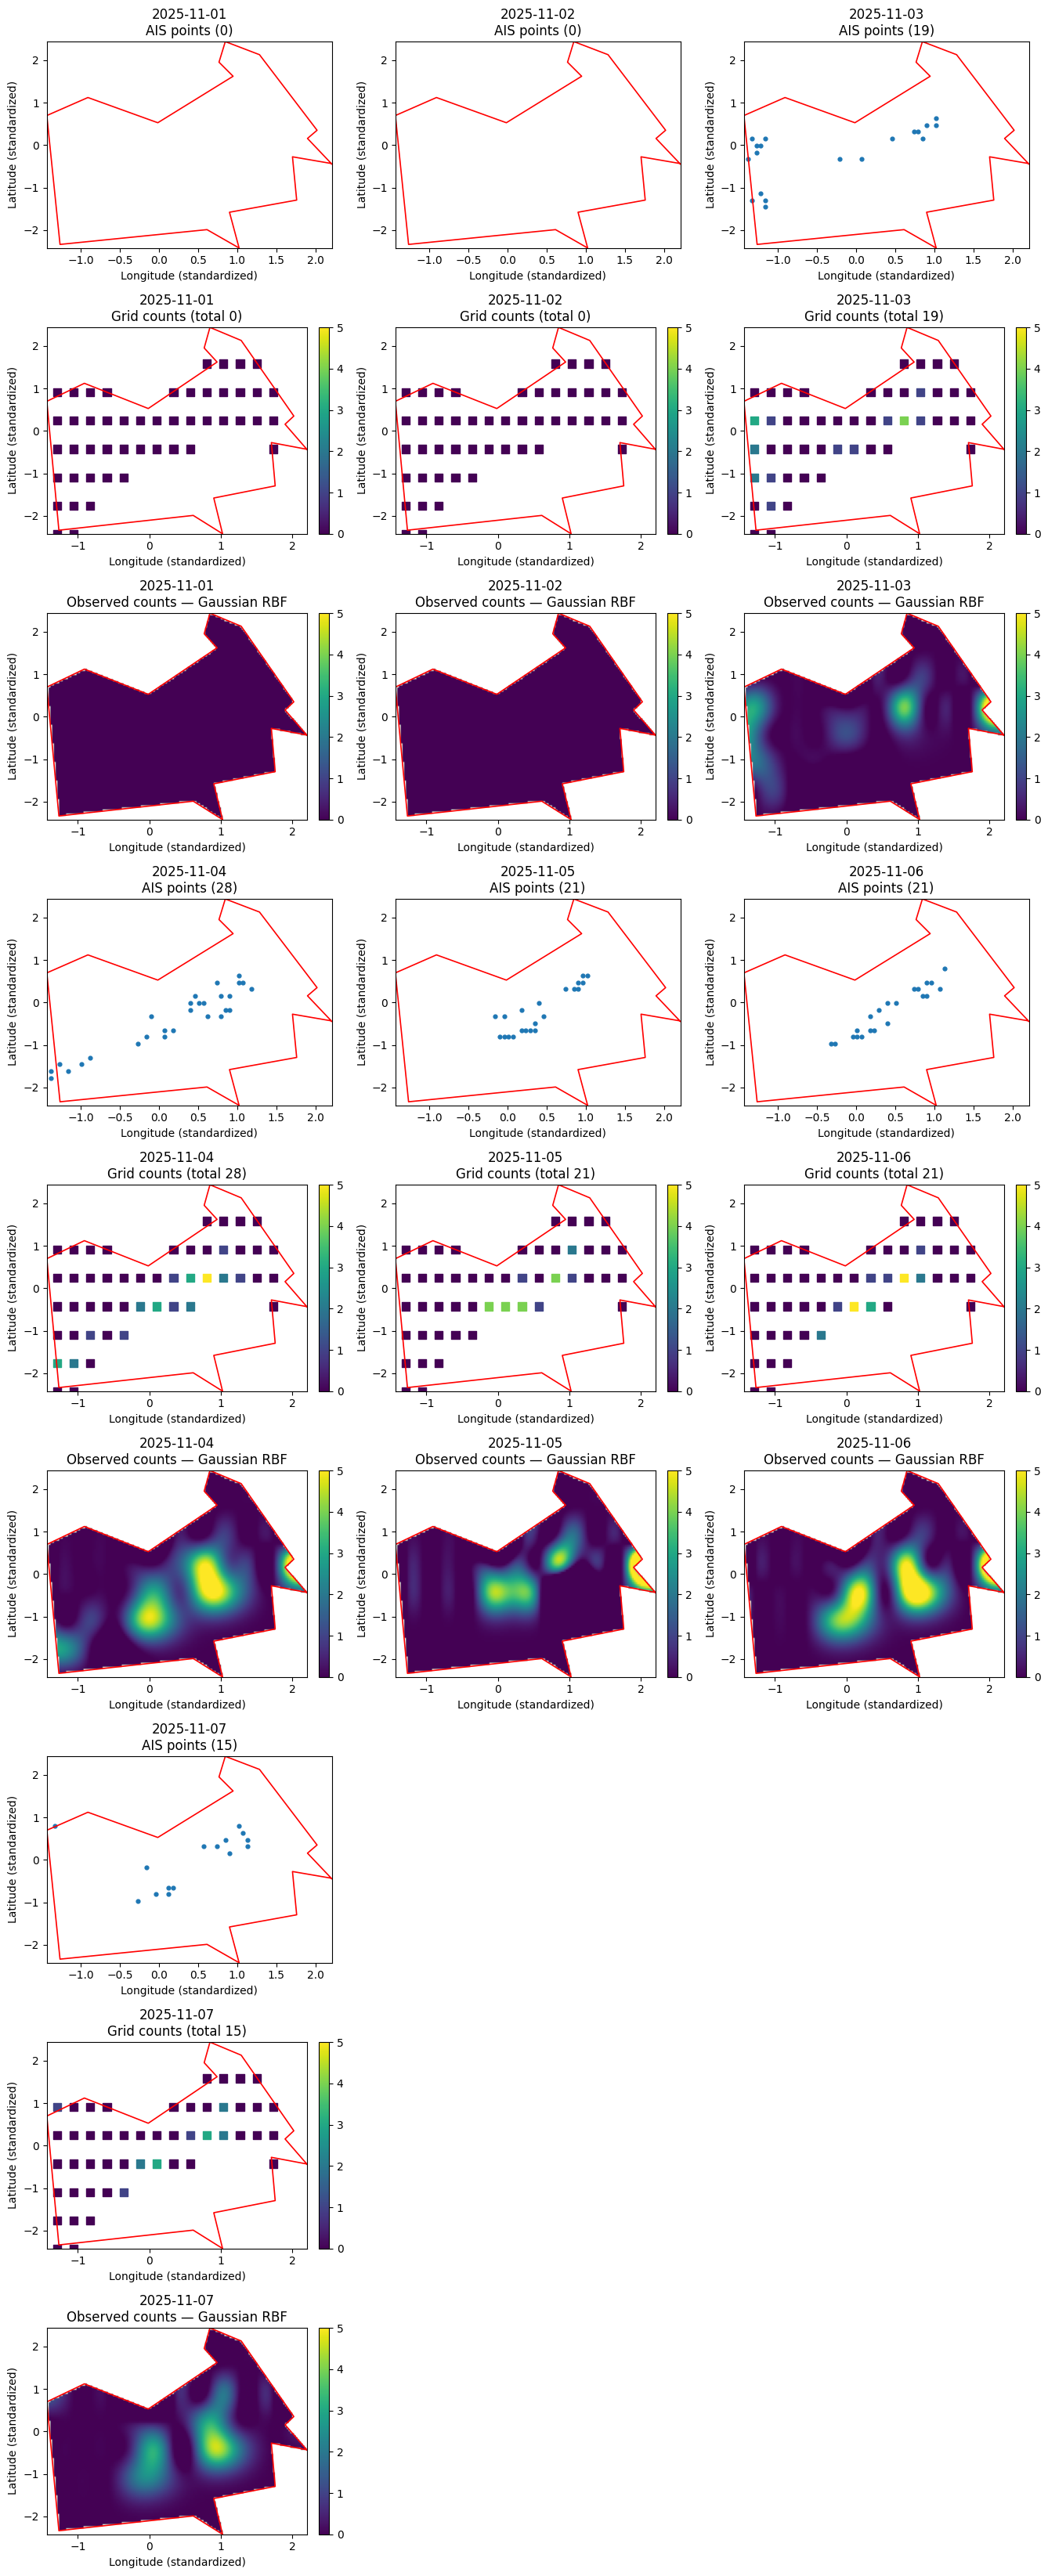

,date,AIS records,grid total,max cell count,max interpolated value
0,2025-11-01,0,0.0,0.0,0.000000
1,2025-11-02,0,0.0,0.0,0.000000
2,2025-11-03,19,19.0,4.0,6.162652
3,2025-11-04,28,28.0,5.0,6.211714
4,2025-11-05,21,21.0,4.0,10.768848
5,2025-11-06,21,21.0,5.0,7.986454
6,2025-11-07,15,15.0,3.0,4.687482


In [80]:
comparison_summary = plot_daily_lgcp_observation_comparison(
    ais=ais,
    config_path='config/exp4.yaml',
    start_date='2025-11-01',
    end_date='2025-11-07',
    ncols=3,
    vmax=5,  # Match the screenshot color scale; None uses max observed count.
)
comparison_summary


## Complete rectangular grid and uniform diffusion

Missing spatial positions start at zero. Each source spreads uniformly across its square neighborhood (radius 1 = 3×3), including virtual cells. Totals are conserved on the full rectangle.

The display now follows the experiment layout: standardized axes, viridis colors, red Gulf boundary, and white outside the Gulf. The first row shows actual cell values; the second uses shape-preserving PCHIP display interpolation of the diffused grid for smoother transitions without overshooting neighboring values. Outside the grid-center bounds the nearest edge value is used. The Gulf mask only hides values; totals in the summary refer to the full rectangle. No RBF interpolation is used.


In [104]:
from scipy.ndimage import convolve
from scipy.interpolate import RegularGridInterpolator, PchipInterpolator
from matplotlib.path import Path as GulfPath


def plot_daily_complete_grid_diffusion(
    frame, gulf_coords, start_date='2025-11-01', end_date='2025-11-07',
    ncols=3, radius_cells=1, vmax=None, render_nx=900, render_ny=600, dpi=160,
    diffusion_strength=1.0, display_method="pchip",
):
    """Fill missing grid positions with zero, then spread each count uniformly.

    radius_cells=1 distributes each source across its 3x3 neighborhood.
    diffusion_strength blends original and spread counts: 0 = unchanged, 1 = full spread.
    At rectangle edges, distribute only among in-bounds cells, conserving total.
    Virtual cells start at zero but can receive counts. Gulf masking is display-only.
    Shape-preserving PCHIP display interpolation softens transitions without RBF overshoot.
    display_method="linear" restores the previous rendering; grid calculations are unchanged.
    """
    if not isinstance(radius_cells, int) or radius_cells < 0:
        raise ValueError('radius_cells must be a nonnegative integer')
    if not np.isfinite(diffusion_strength) or not 0 <= diffusion_strength <= 1:
        raise ValueError('diffusion_strength must be between 0 and 1')
    if display_method not in ("linear", "pchip"):
        raise ValueError("display_method must be linear or pchip")
    if ncols < 1:
        raise ValueError('ncols must be positive')
    if render_nx < 2 or render_ny < 2 or dpi <= 0:
        raise ValueError('Rendering dimensions must be at least 2 and dpi positive')
    data = frame.copy()
    data['date'] = pd.to_datetime(data['date']).dt.normalize()

    def complete_axis(values):
        values = np.sort(np.unique(values.astype(float)))
        if len(values) < 2:
            raise ValueError('At least two coordinates are needed on each axis')
        step = float(np.min(np.diff(values)))
        indices = np.rint((values - values[0]) / step).astype(int)
        if not np.allclose(values, values[0] + indices * step, atol=step * .002, rtol=0):
            raise ValueError('Coordinates do not form a regular grid')
        return values[0] + np.arange(indices.max() + 1) * step, step

    lons, dx = complete_axis(data['longitude'].to_numpy())
    lats, dy = complete_axis(data['latitude'].to_numpy())
    mean = data[['longitude', 'latitude']].mean().to_numpy()
    std = data[['longitude', 'latitude']].std().to_numpy()
    boundary = (gulf_coords[['longitude', 'latitude']].to_numpy() - mean) / std
    xi = np.linspace(boundary[:, 0].min(), boundary[:, 0].max(), render_nx)
    yi = np.linspace(boundary[:, 1].min(), boundary[:, 1].max(), render_ny)
    Xi, Yi = np.meshgrid(xi, yi)
    inside = GulfPath(boundary).contains_points(np.c_[Xi.ravel(), Yi.ravel()]).reshape(Xi.shape)
    # Sample the display surface in physical coordinates, then mask the Gulf.
    query = np.c_[(Yi.ravel() * std[1] + mean[1]).clip(lats[0], lats[-1]),
                  (Xi.ravel() * std[0] + mean[0]).clip(lons[0], lons[-1])]
    days = pd.date_range(start_date, end_date, freq='D')
    if not len(days):
        raise ValueError('Choose a nonempty date range')
    kernel = np.ones((2 * radius_cells + 1, 2 * radius_cells + 1))
    # Normalize each source by its number of in-bounds destinations.
    destinations = convolve(np.ones((len(lats), len(lons))), kernel, mode='constant', cval=0)
    panels, records = [], []
    for day in days:
        daily = data.loc[data['date'] == day]
        if daily.empty:
            raise ValueError(f'No observations for {day.date()}; missing days are not zero days')
        if daily.duplicated(['latitude', 'longitude']).any():
            raise ValueError(f'Duplicate grid cells on {day.date()}')
        counts = daily['ais_vessels_count'].to_numpy(dtype=float)
        if not np.isfinite(counts).all() or (counts < 0).any():
            raise ValueError('Counts must be finite and nonnegative')
        x = np.rint((daily['longitude'].to_numpy() - lons[0]) / dx).astype(int)
        y = np.rint((daily['latitude'].to_numpy() - lats[0]) / dy).astype(int)
        full = np.zeros(destinations.shape)
        present = np.zeros(destinations.shape, dtype=bool)
        full[y, x] = counts
        present[y, x] = True
        spread = convolve(full / destinations, kernel, mode='constant', cval=0)
        spread = (1 - diffusion_strength) * full + diffusion_strength * spread
        np.testing.assert_allclose(spread.sum(), full.sum(), atol=1e-10)
        panels.append((day, full, spread, present))
        records.append({'date': day, 'original cells': int(present.sum()),
                        'virtual cells': int((~present).sum()), 'original total': full.sum(),
                        'spread total': spread.sum(), 'max original': full.max(),
                        'max spread': spread.max()})
    vmax = max(max(p[1].max() for p in panels), 1e-8) if vmax is None else vmax
    fig, axes = plt.subplots(2 * math.ceil(len(days) / ncols), ncols,
                             figsize=(4.8 * ncols, 8 * math.ceil(len(days) / ncols)),
                             squeeze=False, dpi=dpi)
    for ax in axes.flat:
        ax.set_visible(False)
    for i, (day, full, spread, present) in enumerate(panels):
        group, col = divmod(i, ncols)
        for row, (values, title) in enumerate([
            (full, 'Complete grid — virtual cells = 0'),
            (spread, f'Spread — radius {radius_cells}, strength {diffusion_strength:g}'),
        ]):
            ax = axes[2 * group + row, col]
            ax.set_visible(True)
            # Keep original cells discrete; smooth only the display of the diffused grid.
            method = 'nearest' if row == 0 else display_method
            if method == 'pchip' and min(len(lats), len(lons)) < 4:
                method = 'linear'  # PCHIP requires at least four points per axis.
            if method == 'pchip':
                # Separable evaluation avoids a slow Python loop per display pixel.
                display_lons = (xi * std[0] + mean[0]).clip(lons[0], lons[-1])
                display_lats = (yi * std[1] + mean[1]).clip(lats[0], lats[-1])
                along_lon = PchipInterpolator(lons, values, axis=1)(display_lons)
                surface = PchipInterpolator(lats, along_lon, axis=0)(display_lats)
            else:
                surface = RegularGridInterpolator((lats, lons), values, method=method)(query).reshape(Xi.shape)
            surface = np.where(inside, surface, np.nan)
            artist = ax.imshow(surface, origin='lower',
                               extent=[xi.min(), xi.max(), yi.min(), yi.max()],
                               cmap='viridis', vmin=0, vmax=vmax,
                               aspect='auto', interpolation='nearest')
            ax.plot(boundary[:, 0], boundary[:, 1], color='red', lw=1.2)
            ax.set(title=f'{day:%Y-%m-%d}\n{title}',
                   xlabel='Longitude (standardized)', ylabel='Latitude (standardized)',
                   xlim=(xi.min(), xi.max()), ylim=(yi.min(), yi.max()))
            fig.colorbar(artist, ax=ax, fraction=.046, pad=.04)
    fig.tight_layout()
    plt.show()
    return pd.DataFrame(records)


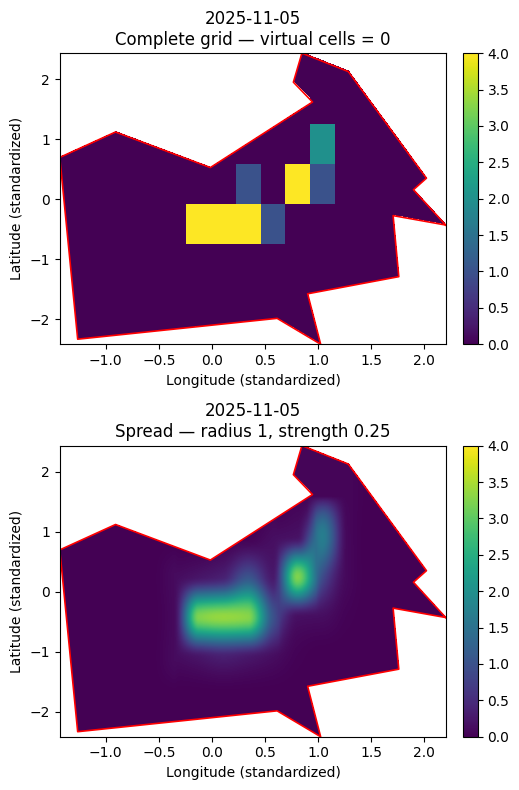

,date,original cells,virtual cells,original total,spread total,max original,max spread
0,2025-11-05,49,49,21.0,21.0,4.0,3.361111


In [121]:
complete_grid_summary = plot_daily_complete_grid_diffusion(
    frame=cpr_gfw,
    gulf_coords=gulf_coords,
    start_date='2025-11-05',
    end_date='2025-11-05',
    ncols=3,
    radius_cells=1,  # Neighborhood size: 1 = 3x3 cells.
    diffusion_strength=0.25,  # 0 = no diffusion; 1 = full uniform spread.
    display_method="pchip",  # Smooth, shape-preserving display; "linear" for previous style.
    vmax=None,
    render_nx=2700,  # Display resolution only; the underlying grid is unchanged.
    render_ny=1800,
    dpi=100,
)
complete_grid_summary


# Marine variables - spatial analysis 

In [12]:
cpr_gfw.head()

,date,is_holiday,holiday_name,is_weekend,fishing_block,latitude,longitude,chl,thetao,sar_vessels_count,ais_vessels_count,DREDGE_FISHING,FISHING,OTHER_PURSE_SEINES,POTS_AND_TRAPS,TRAWLERS
0,2024-01-01,True,New Year's Day,False,False,45.479168,13.166667,0.432612,13.304394,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2024-01-02,False,None,False,False,45.479168,13.166667,0.409951,13.248711,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-01-03,False,None,False,False,45.479168,13.166667,0.387921,13.063446,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2024-01-04,False,None,False,False,45.479168,13.166667,0.367288,12.772483,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2024-01-05,False,None,False,False,45.479168,13.166667,0.347252,13.004619,0.0,0.0,0.0,0.0,0.0,0.0,0.0


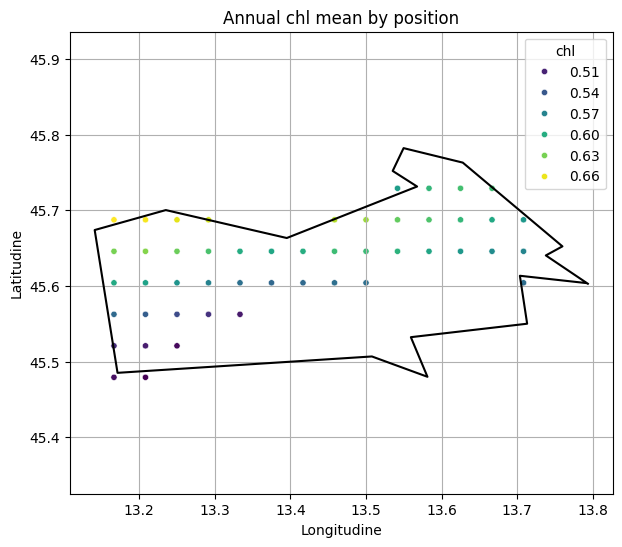

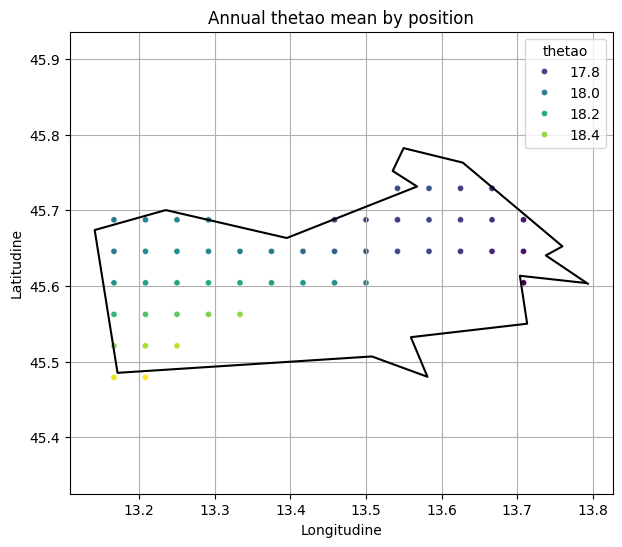

In [13]:
bgc_var_names = ['chl', 'thetao']  # chl, thetao

for bgc_var_name in bgc_var_names:
    df_pos = cpr_gfw.groupby(["latitude", "longitude"], as_index=False)[bgc_var_name].mean()

    plt.figure(figsize=(7, 6))
    
    sns.scatterplot(
        data=df_pos,
        x="longitude",
        y="latitude",
        hue=bgc_var_name,
        palette="viridis",
        s=20
    )
    plt.plot(gulf_coords['longitude'], gulf_coords['latitude'], color = 'black')
    
    plt.xlabel("Longitudine")
    plt.ylabel("Latitudine")
    plt.title(f"Annual {bgc_var_name} mean by position")
    plt.axis("equal")
    plt.grid(True)
    
    plt.show()


# Marine variables - temporal analysis 

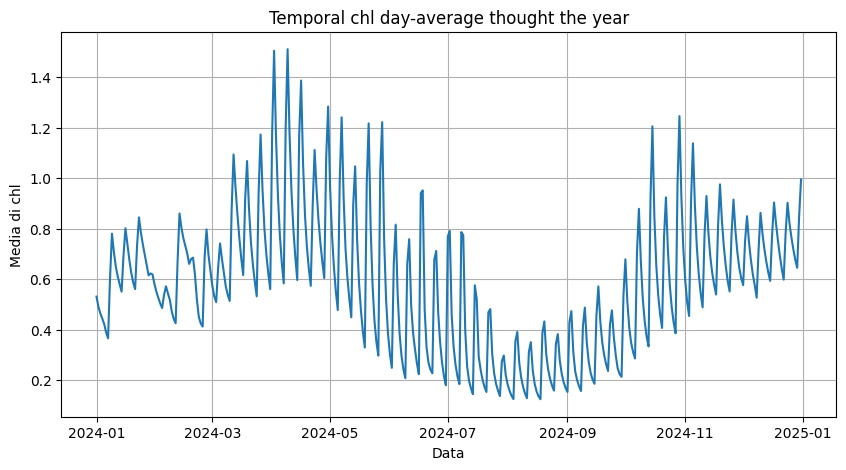

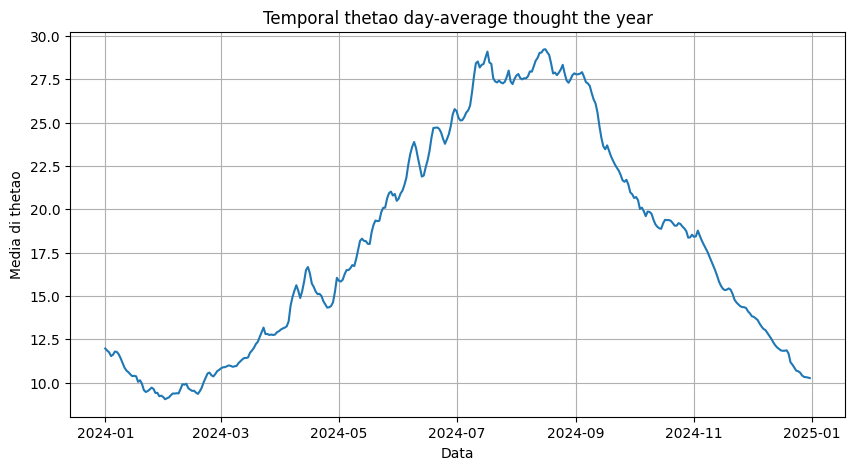

In [14]:
bgc_var_names = ['chl', 'thetao']  # chl, thetao

for bgc_var_name in bgc_var_names:
    df_bgc = cpr_gfw.groupby('date', as_index=False)[bgc_var_name].mean()
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_bgc['date'], df_bgc[bgc_var_name])
    plt.xlabel('Data')
    plt.ylabel(f'Media di {bgc_var_name}')
    plt.title(f'Temporal {bgc_var_name} day-average thought the year')
    plt.grid(True)
    plt.show()

## Chl and ais and sar count 

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


data_inizio = "2024-01-01"
data_fine = "2024-12-31"

vessel_vars = [
    "ais_vessels_count",
    "sar_vessels_count"
]

bgc_var = "chl"


# Assicuro che le date siano in formato datetime
cpr_gfw["date"] = pd.to_datetime(cpr_gfw["date"])
date_flags["date"] = pd.to_datetime(date_flags["date"])

data_inizio = pd.to_datetime(data_inizio)
data_fine = pd.to_datetime(data_fine)


# Filtro il periodo
filtered_cpr_gfw = cpr_gfw[
    (cpr_gfw["date"] >= data_inizio) &
    (cpr_gfw["date"] <= data_fine)
].copy()


for vessel_var in vessel_vars:

    # Somma giornaliera delle barche
    df_vessels = (
        filtered_cpr_gfw
        .groupby("date", as_index=False)[vessel_var]
        .sum()
    )

    # Media giornaliera della clorofilla
    df_chl = (
        filtered_cpr_gfw
        .groupby("date", as_index=False)[bgc_var]
        .mean()
    )

    # Unisco barche, clorofilla e flag temporali
    df_plot = (
        df_vessels
        .merge(df_chl, on="date", how="inner")
        .merge(date_flags, on="date", how="left")
        .sort_values("date")
    )

    # Nel caso ci siano valori mancanti nei flag
    df_plot["is_weekend"] = df_plot["is_weekend"].fillna(False)
    df_plot["is_holiday"] = df_plot["is_holiday"].fillna(False)

    fig, ax_vessels = plt.subplots(figsize=(12, 6))

    # --------------------------------------------------
    # Primo asse: numero di barche
    # --------------------------------------------------
    vessel_line = ax_vessels.plot(
        df_plot["date"],
        df_plot[vessel_var],
        label=vessel_var,
        linewidth=1.5
    )

    ax_vessels.set_xlabel("Data")
    ax_vessels.set_ylabel(f"Somma giornaliera di {vessel_var}")
    ax_vessels.grid(True, alpha=0.3)

    # --------------------------------------------------
    # Secondo asse: clorofilla
    # --------------------------------------------------
    ax_chl = ax_vessels.twinx()

    chl_line = ax_chl.plot(
        df_plot["date"],
        df_plot[bgc_var],
        label="Clorofilla media",
        linestyle="--",
        linewidth=1.5
    )

    ax_chl.set_ylabel("Clorofilla media giornaliera")

    # --------------------------------------------------
    # Marker per weekend e festività
    # --------------------------------------------------
    ymin, ymax = ax_vessels.get_ylim()
    span = ymax - ymin if ymax > ymin else 1.0

    y_weekend = ymin - 0.03 * span
    y_holiday = ymin - 0.07 * span

    ax_vessels.set_ylim(
        y_holiday - 0.02 * span,
        ymax
    )

    weekend_dates = df_plot.loc[
        df_plot["is_weekend"],
        "date"
    ]

    weekend_marker = ax_vessels.scatter(
        weekend_dates,
        np.full(len(weekend_dates), y_weekend),
        marker="|",
        color="orange",
        s=80,
        label="Weekend"
    )

    holiday_dates = df_plot.loc[
        df_plot["is_holiday"],
        "date"
    ]

    holiday_marker = ax_vessels.scatter(
        holiday_dates,
        np.full(len(holiday_dates), y_holiday),
        marker="|",
        color="red",
        s=80,
        label="Holiday"
    )

    # --------------------------------------------------
    # Titolo e legenda comune
    # --------------------------------------------------
    vessel_name = vessel_var.replace("_vessels_count", "").upper()

    ax_vessels.set_title(
        f"Daily {vessel_name} vessels and chlorophyll average"
    )

    handles = (
        vessel_line
        + chl_line
        + [weekend_marker, holiday_marker]
    )

    labels = [
        handle.get_label()
        for handle in handles
    ]

    ax_vessels.legend(
        handles,
        labels,
        loc="upper left"
    )

    fig.tight_layout()
    plt.show()

NameError: name 'date_flags' is not defined

# Gears - temporal analysis 

In [ ]:
cpr_gfw.columns

Index(['date', 'is_holiday', 'holiday_name', 'is_weekend', 'fishing_block',
       'latitude', 'longitude', 'chl', 'thetao', 'sar_vessels_count',
       'ais_vessels_count', 'DREDGE_FISHING', 'FISHING', 'OTHER_PURSE_SEINES',
       'POTS_AND_TRAPS', 'TRAWLERS'],
      dtype='object')

In [ ]:
import numpy as np

# Riassumo per data le info di weekend/festivo (max va bene per bool)
date_flags = (
    cpr_gfw
    .groupby('date', as_index=False)[['is_weekend', 'is_holiday']]
    .max()
)


In [ ]:
cpr_gfw.head()

,date,is_holiday,holiday_name,is_weekend,fishing_block,latitude,longitude,chl,thetao,sar_vessels_count,ais_vessels_count,DREDGE_FISHING,FISHING,OTHER_PURSE_SEINES,POTS_AND_TRAPS,TRAWLERS
0,2024-01-01,True,New Year's Day,False,False,45.479168,13.166667,0.377122,13.599393,0,0,0,0,0,0,0
1,2024-01-01,True,New Year's Day,False,False,45.479168,13.208333,0.376546,13.613258,0,0,0,0,0,0,0
2,2024-01-01,True,New Year's Day,False,False,45.520832,13.166667,0.367301,13.350998,0,0,0,0,0,0,0
3,2024-01-01,True,New Year's Day,False,False,45.520832,13.208333,0.367821,13.401310,0,0,0,0,0,0,0
4,2024-01-01,True,New Year's Day,False,False,45.520832,13.250000,0.368139,13.423026,0,0,0,0,0,0,0


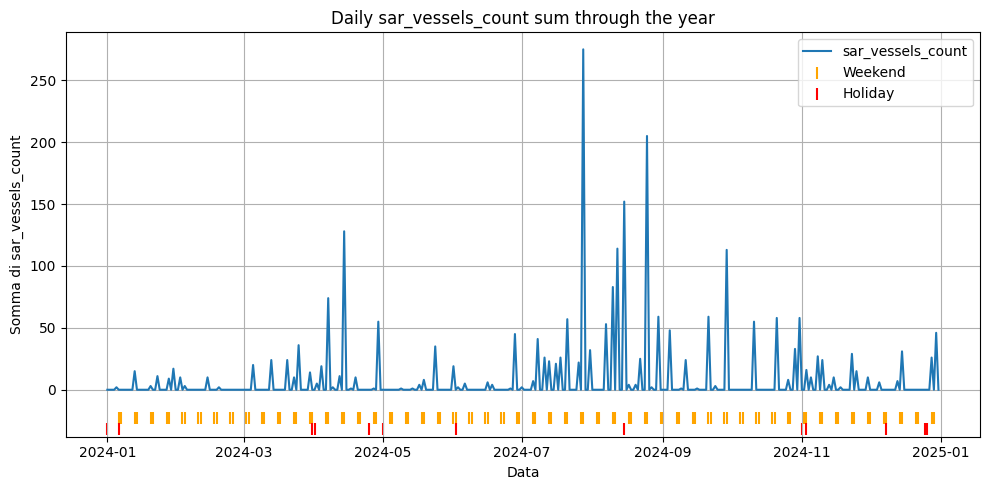

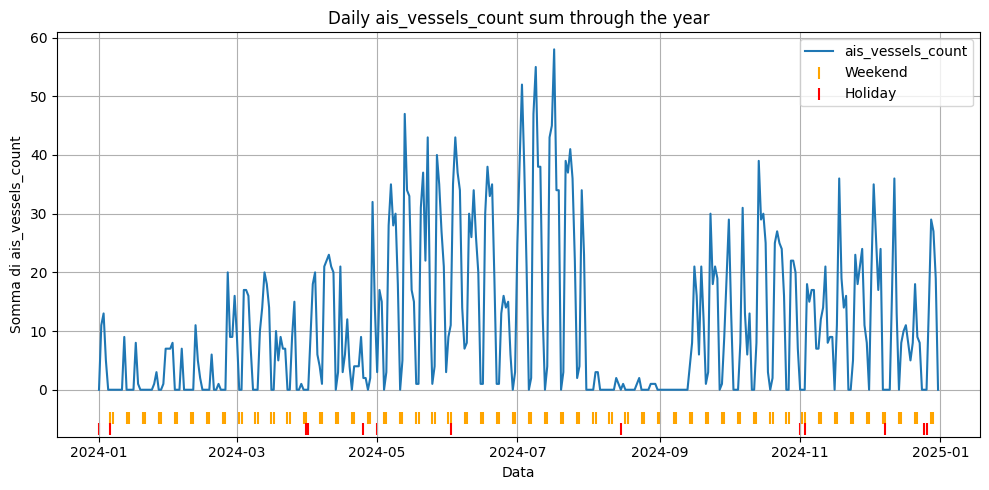

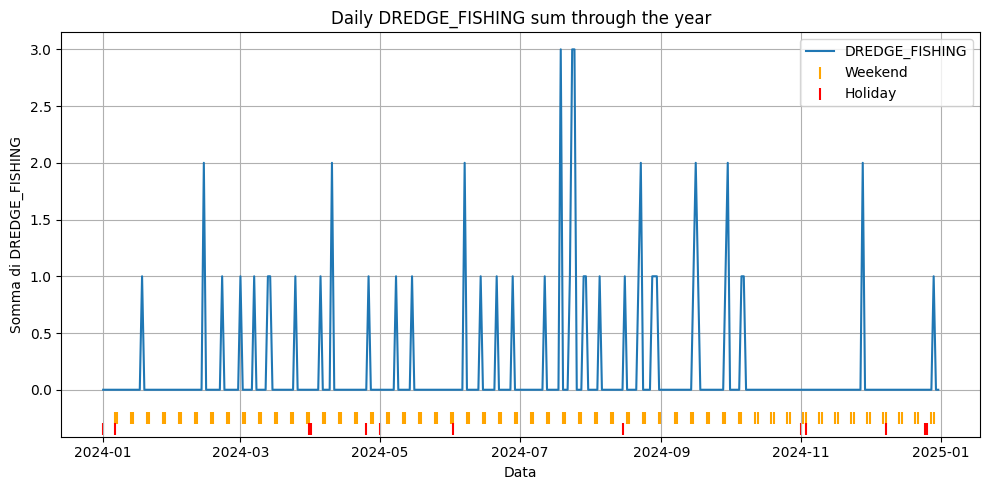

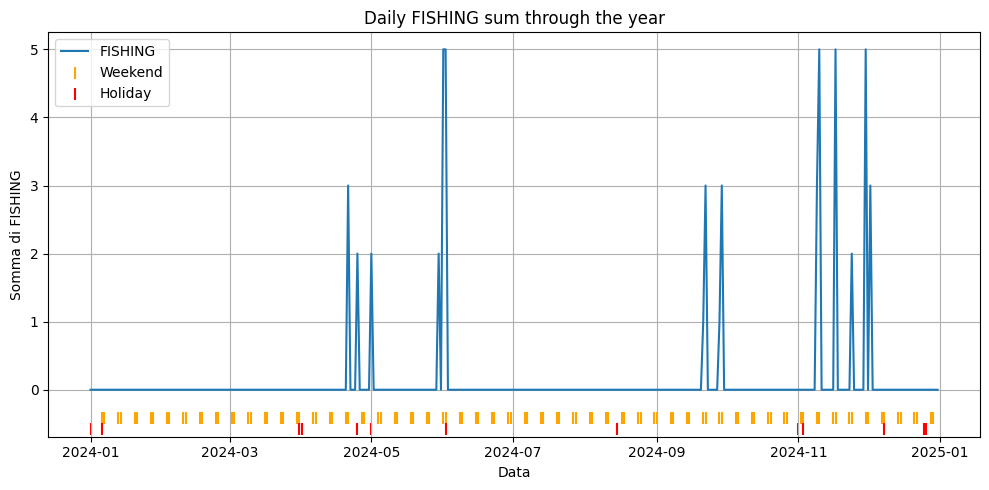

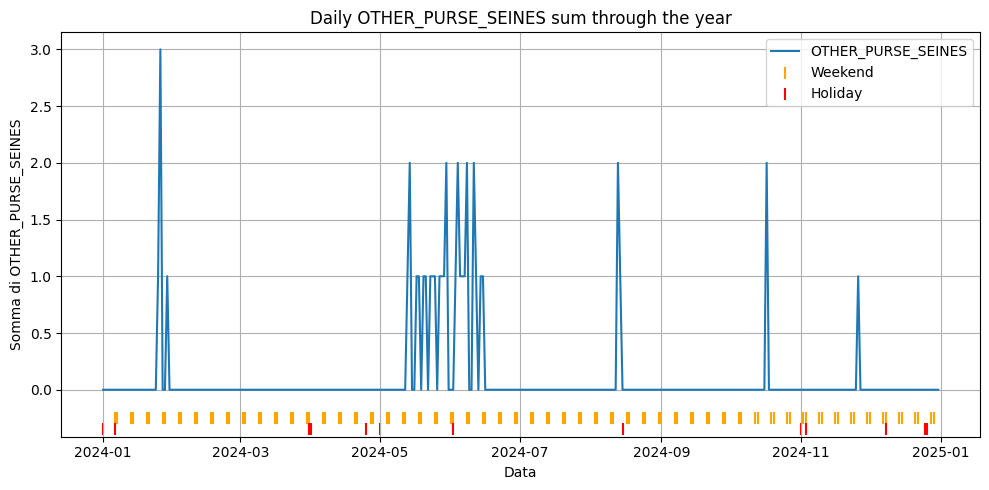

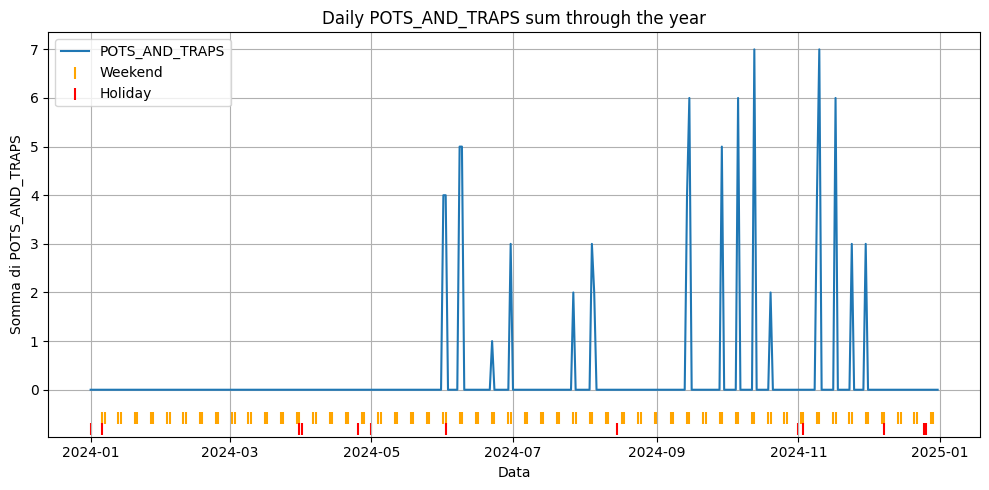

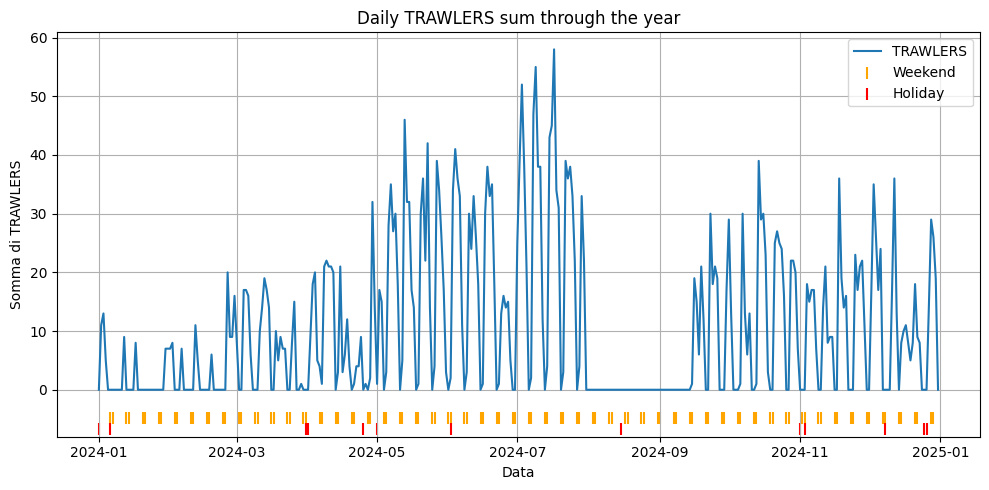

In [ ]:
data_inizio = "2024-01-01"
data_fine = "2024-12-31"
vessel_vars = [ 'sar_vessels_count', 'ais_vessels_count',
       'DREDGE_FISHING', 'FISHING', 'OTHER_PURSE_SEINES', 'POTS_AND_TRAPS',
       'TRAWLERS']  

# ----

filtered_cpr_gfw = cpr_gfw[
    (cpr_gfw["date"] >= data_inizio) &
    (cpr_gfw["date"] <= data_fine)
].copy()
for vessel_var in vessel_vars:
    
    # somma giornaliera
    df_bgc = filtered_cpr_gfw.groupby('date', as_index=False)[vessel_var].sum()
    # aggiungo info weekend/festivi
    df_plot = df_bgc.merge(date_flags, on='date', how='left')
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # linea principale
    ax.plot(df_plot['date'], df_plot[vessel_var], label=vessel_var)
    ax.set_xlabel('Data')
    ax.set_ylabel(f'Somma di {vessel_var}')
    ax.set_title(f'Daily {vessel_var} sum through the year')
    ax.grid(True)

    # prendo i limiti attuali
    ymin, ymax = ax.get_ylim()
    span = ymax - ymin if ymax > ymin else 1.0

    # livelli leggermente sotto la serie per i marker
    y_weekend = ymin - 0.03 * span
    y_holiday = ymin - 0.06 * span

    # aggiusto il limite inferiore per farli vedere
    ax.set_ylim(y_holiday - 0.02 * span, ymax)

    # weekend: piccoli segmenti verticali (marker '|')
    weekend_dates = df_plot.loc[df_plot['is_weekend'], 'date']
    ax.scatter(
        weekend_dates,
        np.full(len(weekend_dates), y_weekend),
        marker='|',
        color='orange',
        s=80,
        label='Weekend'
    )

    # festività: piccoli segmenti verticali (marker '|')
    holiday_dates = df_plot.loc[df_plot['is_holiday'], 'date']
    ax.scatter(
        holiday_dates,
        np.full(len(holiday_dates), y_holiday),
        marker='|',
        color='red',
        s=80,
        label='Holiday'
    )

    # legenda (evito doppioni)
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys())

    plt.tight_layout()
    plt.show()


In [ ]:
print("Medie delle variabili di vessel count nei giorni festivi:")
for vessel_var in vessel_vars:
    print(vessel_var,
    cpr_gfw[
        cpr_gfw['is_holiday'] == True
    ][vessel_var].mean()
    )

print("\nMedie delle variabili di vessel count nei giorni NON festivi:")
for vessel_var in vessel_vars:
    print(vessel_var,
    cpr_gfw[
        cpr_gfw['is_holiday'] == False
    ][vessel_var].mean()
    )

print("\nMedie delle variabili di vessel count nei weekend:")
for vessel_var in vessel_vars:
    print(vessel_var,
    cpr_gfw[
        cpr_gfw['is_weekend'] == True
    ][vessel_var].mean()
    )

print("\nMedie delle variabili di vessel count nei giorni infrasettimanali:")
for vessel_var in vessel_vars:
    print(vessel_var,
    cpr_gfw[
        cpr_gfw['is_weekend'] == False
    ][vessel_var].mean()
    )

print("\nMedie delle variabili di vessel count nei giorni di blocco pesca:")
for vessel_var in vessel_vars:
    print(vessel_var,
    cpr_gfw[
        cpr_gfw['fishing_block'] == True
    ][vessel_var].mean()
    )


print("\nMedie delle variabili di vessel count nei giorni senza blocco pesca:")
for vessel_var in vessel_vars:
    print(vessel_var,
    cpr_gfw[
        cpr_gfw['fishing_block'] == False
    ][vessel_var].mean()
    )



Medie delle variabili di vessel count nei giorni festivi:
sar_vessels_count 0.26373626373626374
ais_vessels_count 0.02511773940345369
DREDGE_FISHING 0.0
FISHING 0.0141287284144427
OTHER_PURSE_SEINES 0.0
POTS_AND_TRAPS 0.006279434850863423
TRAWLERS 0.004709576138147566

Medie delle variabili di vessel count nei giorni NON festivi:
sar_vessels_count 0.14083367057871307
ais_vessels_count 0.23258368503208648
DREDGE_FISHING 0.0030641151644793894
FISHING 0.0023703532404463204
OTHER_PURSE_SEINES 0.0022547262531074754
POTS_AND_TRAPS 0.004509452506214951
TRAWLERS 0.22038503786783836

Medie delle variabili di vessel count nei weekend:
sar_vessels_count 0.24725274725274726
ais_vessels_count 0.05239403453689168
DREDGE_FISHING 0.0007849293563579278
FISHING 0.00804552590266876
OTHER_PURSE_SEINES 0.0009811616954474097
POTS_AND_TRAPS 0.015698587127158554
TRAWLERS 0.026883830455259026

Medie delle variabili di vessel count nei giorni infrasettimanali:
sar_vessels_count 0.10468920392584515
ais_vessels_c

In [ ]:
cpr_gfw.head()

,date,is_holiday,holiday_name,is_weekend,fishing_block,latitude,longitude,chl,thetao,sar_vessels_count,ais_vessels_count,DREDGE_FISHING,FISHING,OTHER_PURSE_SEINES,POTS_AND_TRAPS,TRAWLERS
0,2024-01-01,True,New Year's Day,False,False,45.479168,13.166667,0.377122,13.599393,0,0,0,0,0,0,0
1,2024-01-01,True,New Year's Day,False,False,45.479168,13.208333,0.376546,13.613258,0,0,0,0,0,0,0
2,2024-01-01,True,New Year's Day,False,False,45.520832,13.166667,0.367301,13.350998,0,0,0,0,0,0,0
3,2024-01-01,True,New Year's Day,False,False,45.520832,13.208333,0.367821,13.401310,0,0,0,0,0,0,0
4,2024-01-01,True,New Year's Day,False,False,45.520832,13.250000,0.368139,13.423026,0,0,0,0,0,0,0
